<a href="https://colab.research.google.com/github/peemoshi/ai-ml-internship/blob/main/week-2/2.3-hyperparameter-experiments/hyperparameter_experiments_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 2.3: Hyperparameter Experimentation**

This notebook reuses the CNN architecture from Task 2.2 (trained on CIFAR-10) and tests how different training hyperparameters — learning rate, optimizer choice, and batch size — affect the model's final test accuracy. Each experiment changes exactly one setting at a time from a shared baseline, so any difference in results can be attributed to that one change.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

100%|██████████| 170M/170M [52:28<00:00, 54.2kB/s]


The model architecture is kept identical across every experiment. This isolates the training hyperparameters as the only variable; if the network itself changed between runs too, we wouldn't be able to tell whether a hyperparameter or the architecture caused a difference in performance.

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Rather than repeating the training and evaluation code for every configuration, this function wraps the full training loop and takes the hyperparameters to test as arguments. A fresh, untrained model is created inside the function on every call, ensuring each experiment starts from the same conditions.

In [6]:
def run_experiment(lr, optimizer_name, batch_size, epochs=5):
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy

Four configurations are tested: a baseline (Adam optimizer, learning rate 0.001, batch size 64), then one variant each for a lower learning rate, the SGD optimizer, and a smaller batch size — changing only one setting per variant relative to the baseline.

In [7]:
experiments = [
    {"name": "Baseline",        "lr": 0.001,  "optimizer_name": "adam", "batch_size": 64},
    {"name": "Lower LR",        "lr": 0.0001, "optimizer_name": "adam", "batch_size": 64},
    {"name": "SGD optimizer",   "lr": 0.001,  "optimizer_name": "sgd",  "batch_size": 64},
    {"name": "Smaller batch",   "lr": 0.001,  "optimizer_name": "adam", "batch_size": 32},
]

In [8]:
import time

results = []

for exp in experiments:
    start = time.time()
    accuracy = run_experiment(lr=exp["lr"], optimizer_name=exp["optimizer_name"], batch_size=exp["batch_size"], epochs=5)
    duration = time.time() - start

    results.append({
        "Experiment": exp["name"],
        "Learning Rate": exp["lr"],
        "Optimizer": exp["optimizer_name"],
        "Batch Size": exp["batch_size"],
        "Test Accuracy": round(accuracy, 4),
        "Time (s)": round(duration, 1)
    })

    print(f"{exp['name']} done — accuracy: {accuracy:.4f}")

Baseline done — accuracy: 0.7163
Lower LR done — accuracy: 0.5928
SGD optimizer done — accuracy: 0.5699
Smaller batch done — accuracy: 0.7107


In [9]:
results_df = pd.DataFrame(results)
results_df

,Experiment,Learning Rate,Optimizer,Batch Size,Test Accuracy,Time (s)
0,Baseline,0.0010,adam,64,0.7163,75.5
1,Lower LR,0.0001,adam,64,0.5928,75.0
2,SGD optimizer,0.0010,sgd,64,0.5699,73.5
3,Smaller batch,0.0010,adam,32,0.7107,84.0


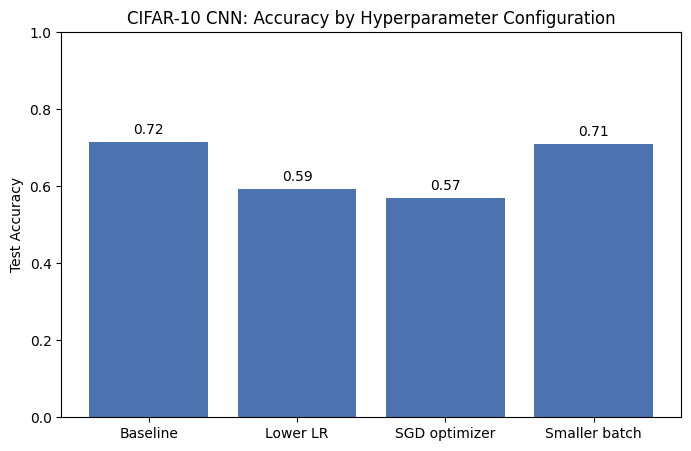

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(results_df["Experiment"], results_df["Test Accuracy"], color="#4C72B0")
plt.ylabel("Test Accuracy")
plt.title("CIFAR-10 CNN: Accuracy by Hyperparameter Configuration")
plt.ylim(0, 1)

for bar, acc in zip(bars, results_df["Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{acc:.2f}", ha="center")

plt.show()

**Summary**

The baseline configuration (Adam, learning rate 0.001, batch size 64) achieved the highest test accuracy (71.6%), with a smaller batch size performing nearly as well (71.1%). Both other variants underperformed the baseline: reducing the learning rate to 0.0001 dropped accuracy to 59.3%, likely because 5 epochs wasn't enough training time for the smaller update steps to converge as far. Switching to SGD dropped accuracy to 57.0%, consistent with SGD typically needing more epochs (or a higher learning rate) than Adam to reach comparable performance. This suggests Adam with a moderate learning rate (~0.001) is a reasonable default for this architecture and dataset, and that a fair comparison of SGD vs. Adam would need a longer training run rather than a fixed 5 epochs.